<a href="https://colab.research.google.com/github/rajmatondkar3-eng/CSL701-CS30_Machine-Learning-Lab/blob/main/Experiments/MLExp01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name :  Raj Shriram Matondkar

Roll No : CS-30

Batch : BE-CSE

In [ ]:
# ============================================
# PHASE 2: ENVIRONMENT SETUP & DATA LOADING
# ============================================

# Task 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Set Seaborn style
sns.set_theme(style="whitegrid")

In [ ]:

# Task 2: Load train.csv into a Pandas DataFrame
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully!\n")

Saving Titanic-Dataset.csv to Titanic-Dataset.csv
Dataset loaded successfully!



In [ ]:

# ============================================
# PHASE 3: DATA INSPECTION
# ============================================

# Task 3: Display first 10 rows
print("TASK 3: First 10 rows")
print(df.head(10))
print("\n")

TASK 3: First 10 rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr.

In [ ]:

# Task 4: Display last 5 rows
print("TASK 4: Last 5 rows")
print(df.tail(5))
print("\n")

TASK 4: Last 5 rows
     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  




In [ ]:

# Task 5: Check dataset dimensions
print("TASK 5: Dataset dimensions")
print("Shape:", df.shape)
print("\n")


TASK 5: Dataset dimensions
Shape: (891, 12)




In [ ]:

# Task 6: Display dataset information
print("TASK 6: Dataset information")
df.info()
print("\n")


TASK 6: Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB




In [ ]:

# Task 7: Generate summary statistics
print("TASK 7: Summary statistics")
print(df.describe())
print("\n")

# Record mean, minimum and maximum values of Age
print("Age Statistics:")
print("Mean Age:", df["Age"].mean())
print("Minimum Age:", df["Age"].min())
print("Maximum Age:", df["Age"].max())

print("\nFare Statistics:")
print("Mean Fare:", df["Fare"].mean())
print("Minimum Fare:", df["Fare"].min())
print("Maximum Fare:", df["Fare"].max())
print("\n")


TASK 7: Summary statistics
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


Age Statistics:
Mean Age: 29.69911764705882
Minimum 

In [ ]:

# Task 8: Identify missing values
print("TASK 8: Missing values")
print(df.isnull().sum())
print("\n")

TASK 8: Missing values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64




In [ ]:

# ============================================
# PHASE 4: DATA MANIPULATION & CLEANING
# ============================================

# Task 9: Fill missing Age values with the median
age_median = df["Age"].median()

df["Age"] = df["Age"].fillna(age_median)

print("TASK 9: Missing Age values filled")
print("Median Age:", age_median)
print("Remaining missing Age values:", df["Age"].isnull().sum())
print("\n")

TASK 9: Missing Age values filled
Median Age: 28.0
Remaining missing Age values: 0




In [ ]:

# Task 10: Filter surviving passengers
survived_passengers = df[df["Survived"] == 1]

print("TASK 10: Surviving passengers")
print(survived_passengers.head())
print("Number of surviving passengers:", len(survived_passengers))
print("\n")

TASK 10: Surviving passengers
   PassengerId  Survived  Pclass  \
1            2         1       1   
2            3         1       3   
3            4         1       1   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)  female  27.0      0   
9                Nasser, Mrs. Nicholas (Adele Achem)  female  14.0      1   

   Parch            Ticket     Fare Cabin Embarked  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
8      2            347742  11.1333   NaN        S  
9      0            23773

In [ ]:


# Task 11: Convert Fare column to NumPy array
fare_array = df["Fare"].to_numpy()

print("TASK 11: Fare as NumPy array")
print(fare_array)
print("\n")

TASK 11: Fare as NumPy array
[  7.25    71.2833   7.925   53.1      8.05     8.4583  51.8625  21.075
  11.1333  30.0708  16.7     26.55     8.05    31.275    7.8542  16.
  29.125   13.      18.       7.225   26.      13.       8.0292  35.5
  21.075   31.3875   7.225  263.       7.8792   7.8958  27.7208 146.5208
   7.75    10.5     82.1708  52.       7.2292   8.05    18.      11.2417
   9.475   21.       7.8958  41.5792   7.8792   8.05    15.5      7.75
  21.6792  17.8     39.6875   7.8     76.7292  26.      61.9792  35.5
  10.5      7.2292  27.75    46.9      7.2292  80.      83.475   27.9
  27.7208  15.2458  10.5      8.1583   7.925    8.6625  10.5     46.9
  73.5     14.4542  56.4958   7.65     7.8958   8.05    29.      12.475
   9.       9.5      7.7875  47.1     10.5     15.85    34.375    8.05
 263.       8.05     8.05     7.8542  61.175   20.575    7.25     8.05
  34.6542  63.3583  23.      26.       7.8958   7.8958  77.2875   8.6542
   7.925    7.8958   7.65     7.775    7.8958 

In [ ]:

# Task 12: Calculate maximum and average Fare
maximum_fare = np.max(fare_array)
average_fare = np.mean(fare_array)

print("TASK 12: Fare statistics")
print("Maximum Fare:", maximum_fare)
print("Average Fare:", average_fare)
print("\n")

TASK 12: Fare statistics
Maximum Fare: 512.3292
Average Fare: 32.204207968574636




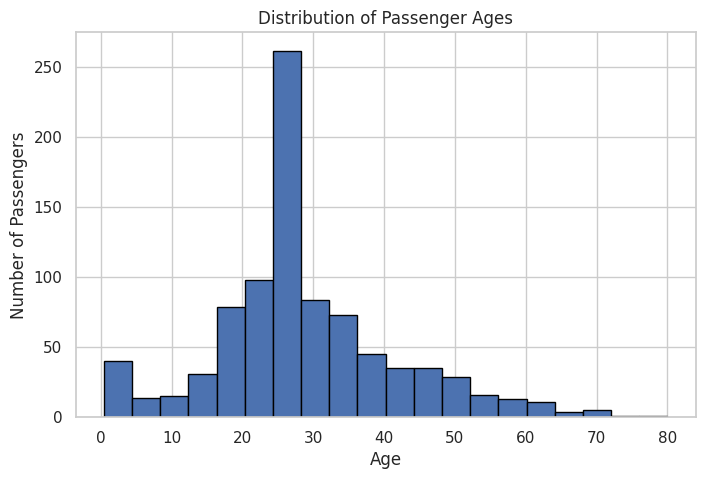

In [ ]:

# ============================================
# PHASE 5: DATA VISUALIZATION
# ============================================

# Task 13: Plot histogram of Age
plt.figure(figsize=(8, 5))

plt.hist(df["Age"], bins=20, edgecolor="black")

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()





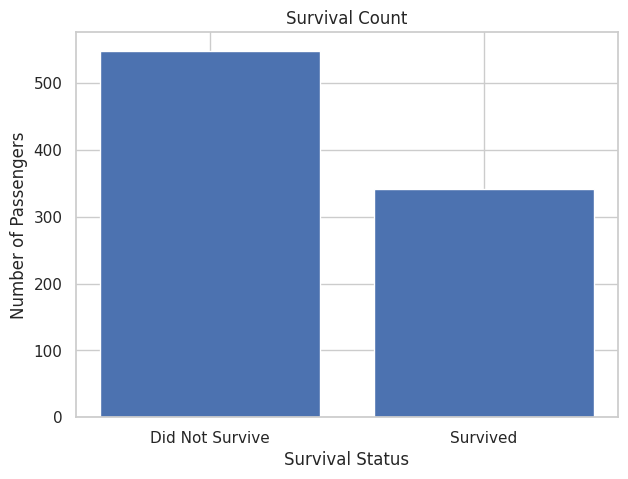

In [ ]:

# Task 14: Plot bar chart of Survival Count
survival_count = df["Survived"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Did Not Survive", "Survived"],
    survival_count.values
)

plt.title("Survival Count")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.show()

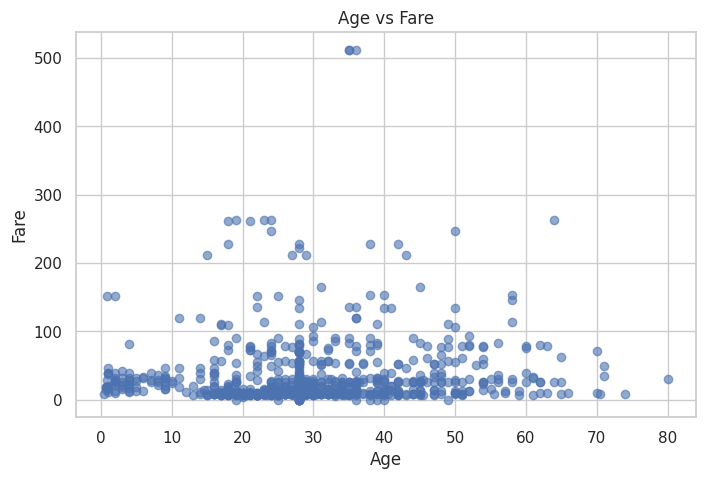

In [ ]:

# Task 15: Plot scatter graph of Age vs Fare
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age"],
    df["Fare"],
    alpha=0.6
)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()